In [1]:
import sys
sys.path.append('../')
from datasets import load_dataset
from xsbert import models, utils
from sentence_transformers.models import Pooling
import torch
import random
from pprint import pprint

/mount/arbeitsdaten/tcl/Users/moellels/anaconda/envs/emb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# SBERT model
model_name = 'sentence-transformers/msmarco-MiniLM-L12-cos-v5'
transformer = models.ReferenceTransformer(model_name)
pooling = Pooling(transformer.get_word_embedding_dimension())
model = models.XSRoberta(modules=[transformer, pooling])

In [2]:
# Jina v2 model
model_name = 'jinaai/jina-embeddings-v2-base-en'
transformer = models.ReferenceTransformer(model_name)
pooling = Pooling(transformer.get_word_embedding_dimension())
model = models.XJina(modules=[transformer, pooling])

Some weights of BertModel were not initialized from the model checkpoint at jinaai/jina-embeddings-v2-base-en and are newly initialized: ['embeddings.position_embeddings.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.intermediate.dense.weight', 'encoder.layer.0.output.LayerNorm.bias', 'encoder.layer.0.output.LayerNorm.weight', 'encoder.layer.0.output.dense.bias', 'encoder.layer.0.output.dense.weight', 'encoder.layer.1.intermediate.dense.bias', 'encoder.layer.1.intermediate.dense.weight', 'encoder.layer.1.output.LayerNorm.bias', 'encoder.layer.1.output.LayerNorm.weight', 'encoder.layer.1.output.dense.bias', 'encoder.layer.1.output.dense.weight', 'encoder.layer.10.intermediate.dense.bias', 'encoder.layer.10.intermediate.dense.weight', 'encoder.layer.10.output.LayerNorm.bias', 'encoder.layer.10.output.LayerNorm.weight', 'encoder.layer.10.output.dense.bias', 'encoder.layer.10.output.dense.weight', 'encoder.layer.11.intermediate.dense.bias', 'encoder.layer.11.intermedi

In [3]:
device = torch.device('cuda:4')
model.to(device)

XJina(
  (0): Transformer({'max_seq_length': 8192, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)

In [4]:
ds = load_dataset("microsoft/ms_marco", "v1.1")

In [5]:
ds['test'][0]

{'answers': ['Yes'],
 'passages': {'is_selected': [0, 0, 1, 0, 0, 0, 0],
  'passage_text': ['We have been feeding our back yard squirrels for the fall and winter and we noticed that a few of them have missing fur. One has a patch missing down his back and under both arms. Also another has some missing on his whole chest. They are all eating and seem to have a good appetite.',
   'Critters cannot stand the smell of human hair, so sprinkling a barrier of hair clippings around your garden, or lightly working it into the soil when you plant bulbs, apparently does have some merit. The whole thing kind of makes me laugh. It never occurred to me that we are the ones that stink.',
   "Spread some human hair around your vegetable and flower gardens. This will scare the squirrels away because humans are predators of squirrels. It is better if the hair hasn't been washed so the squirrels will easily pick up the human scent.",
   '1 You can sprinkle blood meal around your garden as well. 2  Don’t 

In [6]:
split = 'test'
# idx = 0
idx = random.randint(0, len(ds[split]) - 1)
inst = ds[split][idx]
query = inst['query']
passage_idx = random.randint(0, len(inst['passages']) - 1)
passage_label = inst['passages']['is_selected'][passage_idx]
passage = inst['passages']['passage_text'][passage_idx]

In [7]:
model.reset_attribution()
model.init_attribution_to_layer(idx=10, N_steps=10)

No hook has been registered.


In [8]:
A, tokens_a, tokens_b = model.explain_similarity(
    query, 
    passage, 
    move_to_cpu=True,
    sim_measure='cos',
    device=device
)

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
100%|██████████| 768/768 [00:03<00:00, 194.58it/s]


'Query:\nwhen is the first mmr vaccine given'
('Passage:\n'
 'The first dose of measles-containing vaccine should be administered at 12 to '
 '15 months of age and the second dose at 18 months of age or any time '
 'thereafter, but should be given no later than around school entry. The '
 'recommended minimum interval between doses of MMR vaccine is 4 weeks. How. '
 '1  Routine childhood immunization: administer two doses of '
 'measles-containing vaccine (MMR or MMRV); the first dose at 12 to 15 months '
 'of age and the second dose at 18 months of age or any time thereafter, but '
 'should be given not')
'Passage Label: 0'


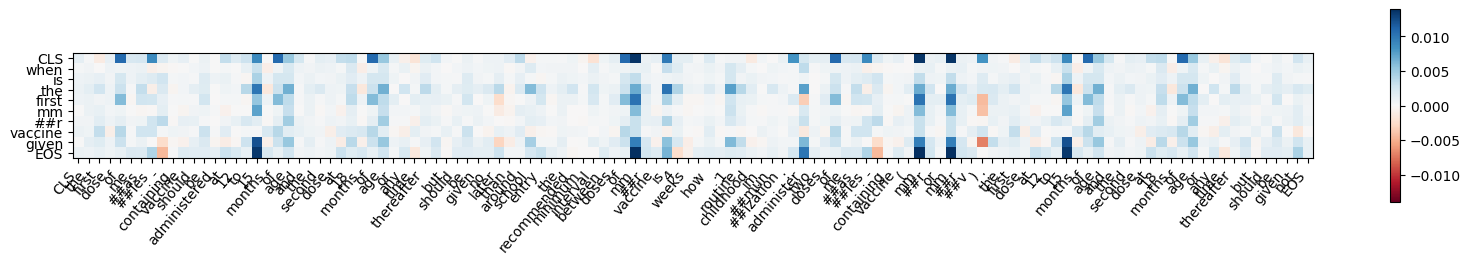

In [9]:
f = utils.plot_attributions(
    A, 
    tokens_a, 
    tokens_b, 
    size=(20, 5), 
    range=None, 
    show_colorbar=True, 
    shrink_colorbar=.5,
)
f.show()
pprint(f"Query:\n{query}")
pprint(f"Passage:\n{passage}")
pprint(f"Passage Label: {passage_label}")

In [17]:
A.isnan().any()

tensor(False)